**Choosing AP Axis**

In [2]:
mean_shape =r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Visualization_of_p_values\mean_shape.stl"

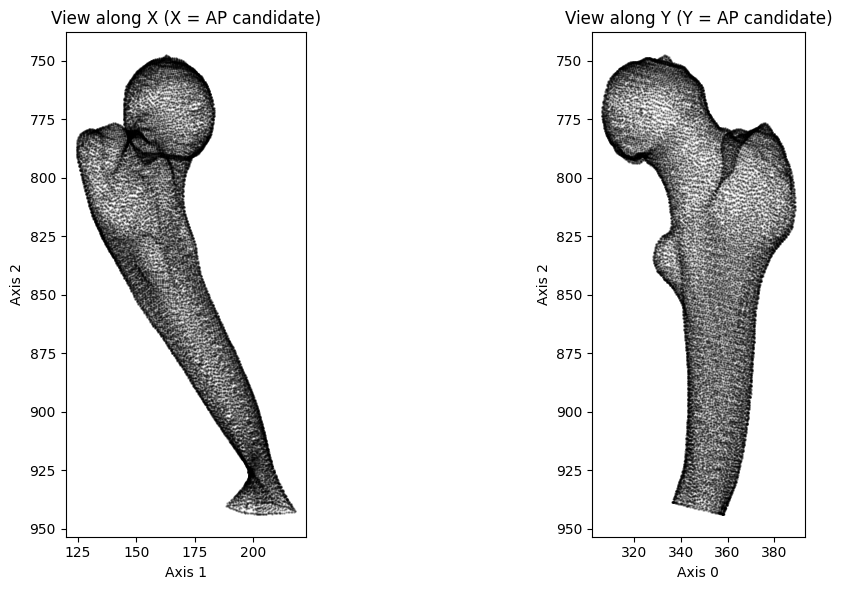

Bounds: [[306.34036255 124.47596741 747.59820557]
 [388.78631592 217.84857178 943.53649902]]
Extents: [ 82.44595337  93.37260437 195.93829346]


In [3]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

# Load your mean shape mesh
mesh = trimesh.load(mean_shape)  # adjust path

vertices = mesh.vertices

def render_projection(vertices, axis, ax, title):
    """
    Project vertices onto plane perpendicular to `axis` and plot silhouette.
    axis: 0=X, 1=Y, 2=Z
    """
    other_axes = [i for i in range(3) if i != axis]
    proj = vertices[:, other_axes]  # 2D points after dropping the viewing axis

    ax.scatter(proj[:, 0], proj[:, 1], s=0.5, alpha=0.3, c='black')
    ax.set_title(title)
    ax.set_xlabel(f'Axis {other_axes[0]}')
    ax.set_ylabel(f'Axis {other_axes[1]}')
    ax.set_aspect('equal')
    ax.invert_yaxis()  # so shaft appears vertical, head/proximal at top if low Z

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# View 1: looking along X axis (i.e., X is the viewing/AP axis)
render_projection(vertices, axis=0, ax=axes[0], title='View along X (X = AP candidate)')

# View 2: looking along Y axis (i.e., Y is the viewing/AP axis)
render_projection(vertices, axis=1, ax=axes[1], title='View along Y (Y = AP candidate)')

plt.tight_layout()
plt.savefig('ap_axis_candidates.png', dpi=150)
plt.show()

print("Bounds:", mesh.bounds)
print("Extents:", mesh.extents)

In [4]:
# Quantify which axis gives a more elongated (less circular) cross-section
# by checking spread ratio at a mid-shaft slice
z_mid = (mesh.bounds[0][2] + mesh.bounds[1][2]) / 2
slice_mask = np.abs(vertices[:, 2] - z_mid) < 5  # 5mm band around mid-shaft
slice_pts = vertices[slice_mask]

x_spread = slice_pts[:, 0].max() - slice_pts[:, 0].min()
y_spread = slice_pts[:, 1].max() - slice_pts[:, 1].min()
print(f"X spread at mid-shaft: {x_spread:.2f}mm")
print(f"Y spread at mid-shaft: {y_spread:.2f}mm")

X spread at mid-shaft: 44.19mm
Y spread at mid-shaft: 36.68mm


**Visualizing Voxelized image**

Mesh bounds: [[306.34036255 124.47596741 747.59820557]
 [388.78631592 217.84857178 943.53649902]]
Mesh extents: [ 82.44595337  93.37260437 195.93829346]
Watertight: False
Watertight after fill_holes: False
Voxel grid shape: (84, 95, 197)
Voxel grid matrix dtype: bool
Number of filled voxels: 172143


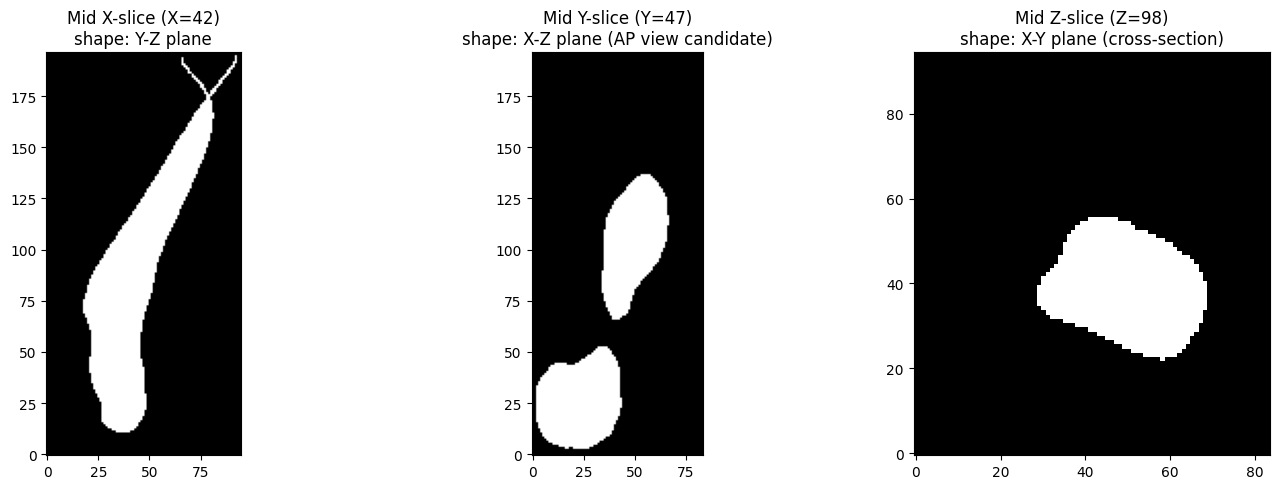

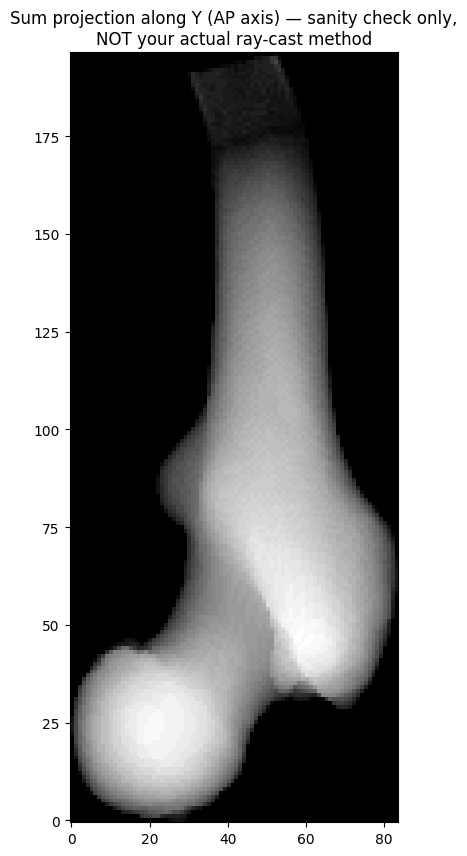

In [5]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

# --- Load mean mesh ---
mesh = trimesh.load(mean_shape, process=True)
print("Mesh bounds:", mesh.bounds)
print("Mesh extents:", mesh.extents)

# Sanity check: mesh must be watertight for solid voxelization
print("Watertight:", mesh.is_watertight)
if not mesh.is_watertight:
    print("WARNING: mesh not watertight — voxelization may produce a hollow/incorrect fill.")
    # Optional fallback: attempt repair
    mesh.fill_holes()
    print("Watertight after fill_holes:", mesh.is_watertight)

# --- Voxelize at 1mm pitch ---
PITCH = 1  # mm, as locked in your design

voxel_grid = mesh.voxelized(pitch=PITCH)

# Fill the interior so you get a solid volume, not just a hollow shell
# (matters for ray-casting attenuation accumulation later)
filled = voxel_grid.fill()

print("Voxel grid shape:", filled.shape)
print("Voxel grid matrix dtype:", filled.matrix.dtype)
print("Number of filled voxels:", filled.matrix.sum())

# matrix is a boolean 3D array — True where solid bone exists
voxel_matrix = filled.matrix  # shape: (nx, ny, nz)

# Save for next steps (ray-caster will load this)
np.save('mean_shape_voxels.npy', voxel_matrix)

# --- Visual verification: 3 orthogonal slices through the volume ---
nx, ny, nz = voxel_matrix.shape
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(voxel_matrix[nx // 2, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Mid X-slice (X={nx//2})\nshape: Y-Z plane')

axes[1].imshow(voxel_matrix[:, ny // 2, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'Mid Y-slice (Y={ny//2})\nshape: X-Z plane (AP view candidate)')

axes[2].imshow(voxel_matrix[:, :, nz // 2].T, cmap='gray', origin='lower')
axes[2].set_title(f'Mid Z-slice (Z={nz//2})\nshape: X-Y plane (cross-section)')

plt.tight_layout()
plt.savefig('voxel_verification_slices.png', dpi=150)
plt.show()

# --- Also verify a projection sum along Y (your AP axis) looks like a femur silhouette ---
ap_projection = voxel_matrix.sum(axis=1)  # sum along Y axis
plt.figure(figsize=(6, 10))
plt.imshow(ap_projection.T, cmap='gray', origin='lower')
plt.title('Sum projection along Y (AP axis) — sanity check only,\nNOT your actual ray-cast method')
plt.savefig('ap_projection_sanity_check_1.0_pitch.png', dpi=150)
plt.show()

**Basic Checks**

In [12]:
import trimesh
import numpy as np

mesh = trimesh.load(mean_shape)

# Find boundary loops
outline = mesh.outline()
print("Number of boundary loops:", len(outline.entities))

# Use first boundary loop
loop_vertices_idx = outline.entities[0].points
loop_pts = mesh.vertices[loop_vertices_idx]

# Create cap centroid
centroid = loop_pts.mean(axis=0)
new_vertex_idx = len(mesh.vertices)

# Create fan triangles
new_faces = []
skipped = 0

for i in range(len(loop_vertices_idx)):
    a = loop_vertices_idx[i]
    b = loop_vertices_idx[(i + 1) % len(loop_vertices_idx)]

    pa = mesh.vertices[a]
    pb = mesh.vertices[b]

    area = 0.5 * np.linalg.norm(np.cross(pb - pa, centroid - pa))

    if area < 1e-6:
        skipped += 1
        continue

    new_faces.append([a, b, new_vertex_idx])

print(f"Skipped {skipped} degenerate fan triangles")

# Add centroid vertex
new_vertices = np.vstack([mesh.vertices, centroid])

# Combine old + new faces
new_faces_arr = np.vstack([
    mesh.faces,
    np.array(new_faces, dtype=np.int64)
])

# Create mesh
capped_mesh = trimesh.Trimesh(
    vertices=new_vertices,
    faces=new_faces_arr,
    process=True
)

# Cleanup for trimesh 4.12.2
capped_mesh.update_faces(capped_mesh.unique_faces())
capped_mesh.update_faces(capped_mesh.nondegenerate_faces())
capped_mesh.remove_unreferenced_vertices()

# Fix normals
capped_mesh.fix_normals()

# Diagnostics
print("Watertight:", capped_mesh.is_watertight)
print("Euler number:", capped_mesh.euler_number)
print("Winding consistent:", capped_mesh.is_winding_consistent)
print("Body count:", capped_mesh.body_count)
print("Extents:", capped_mesh.extents)
print("Original extents:", mesh.extents)

# Save
capped_mesh.export("mean_shape_capped_v2.stl")
print("Saved: mean_shape_capped_v2.stl")

Number of boundary loops: 1
Skipped 1 degenerate fan triangles
Watertight: True
Euler number: 2
Winding consistent: True
Body count: 1
Extents: [ 82.44595337  93.37260437 195.93829346]
Original extents: [ 82.44595337  93.37260437 195.93829346]
Saved: mean_shape_capped_v2.stl


**Grid shape and filled voxel count**

In [13]:
mesh = trimesh.load('mean_shape_capped_v2.stl')

PITCH = 1
voxel_grid = mesh.voxelized(pitch=PITCH)
filled = voxel_grid.fill()

print("Voxel grid shape:", filled.shape)
print("Number of filled voxels:", filled.matrix.sum())

voxel_matrix = filled.matrix
np.save('mean_shape_voxels.npy', voxel_matrix)

Voxel grid shape: (84, 95, 197)
Number of filled voxels: 175794


In [31]:
import trimesh
import numpy as np

mesh = trimesh.load('mean_shape_capped_v2.stl', process=True)
voxel_grid = mesh.voxelized(pitch=1.0)

shell_count = voxel_grid.matrix.sum()   # capture BEFORE fill
shell_matrix = voxel_grid.matrix.copy() # also keep a copy for comparison

voxel_grid.fill()  # mutates in place
filled_count = voxel_grid.matrix.sum()  # capture AFTER

print("shell:", shell_count, "filled:", filled_count)

shell: 32949 filled: 175794


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Text(0.5, 1.0, 'Mid-shaft slice (z=98)')

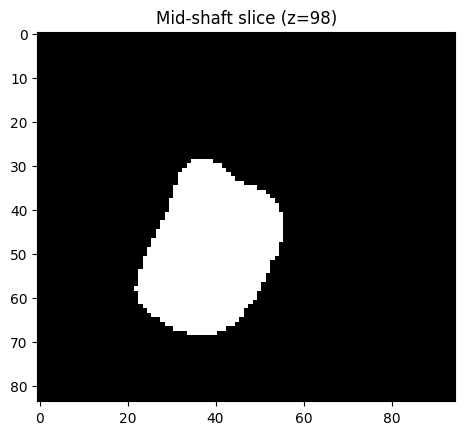

In [32]:
filled_matrix = voxel_grid.matrix  # already mutated in place
mid = filled_matrix.shape[2] //2
slice_2d = filled_matrix[:, :, mid].astype(int)
print(slice_2d)

# quick visual sanity - should look like a solid blob, not a ring
import matplotlib.pyplot as plt
plt.imshow(slice_2d, cmap='gray')
plt.title(f'Mid-shaft slice (z={mid})')

In [35]:
AP_axis = 1  # Y-axis, confirm this matches your locked convention (index into extent array)
in_plane_axes = [i for i in range(3) if i != AP_axis]

# The two in-plane extents project onto the detector
extent_a = extent[in_plane_axes[0]]
extent_b = extent[in_plane_axes[1]]
SDD=1000;SOD=800
magnification = SDD / SOD  # 1000/800 = 1.25

projected_a = extent_a * magnification
projected_b = extent_b * magnification

# Detector must cover the LARGER projected dimension, with margin
margin_factor = 1.2  # 20% margin so bone isn't touching frame edge
detector_fov_mm = max(projected_a, projected_b) * margin_factor

pixel_spacing = detector_fov_mm / 256

print(f"extent_a={extent_a:.2f}mm, extent_b={extent_b:.2f}mm")
print(f"projected: {projected_a:.2f}mm x {projected_b:.2f}mm")
print(f"pixel_spacing = {pixel_spacing:.4f} mm/pixel")

extent_a=82.45mm, extent_b=195.94mm
projected: 103.06mm x 244.92mm
pixel_spacing = 1.1481 mm/pixel


**Cone beam projection code for generating Test DRR**

In [36]:
import torch

def cone_beam_project_torch(volume, voxel_pitch, sdd, sod, pixel_spacing,
                              output_size=(256, 256), ap_axis=1, device='cuda'):
    """
    volume: 3D numpy array or torch tensor (filled voxel grid, binary/density)
    Returns: (H, W) torch tensor DRR image
    """
    vol = torch.as_tensor(volume, dtype=torch.float32, device=device)
    vol_shape = torch.tensor(vol.shape, dtype=torch.float32, device=device)
    vol_center = vol_shape / 2.0

    H, W = output_size
    other_axes = [i for i in range(3) if i != ap_axis]

    # source position (voxel units)
    source = torch.zeros(3, device=device)
    source[ap_axis] = -sod / voxel_pitch

    # build detector pixel grid (physical mm -> voxel units)
    rows = torch.arange(H, device=device, dtype=torch.float32)
    cols = torch.arange(W, device=device, dtype=torch.float32)
    det_v = (rows - H / 2 + 0.5) * pixel_spacing / voxel_pitch   # (H,)
    det_u = (cols - W / 2 + 0.5) * pixel_spacing / voxel_pitch   # (W,)

    det_pos = torch.zeros(H, W, 3, device=device)
    det_pos[:, :, ap_axis] = (sdd - sod) / voxel_pitch
    det_pos[:, :, other_axes[0]] = det_u.view(1, W)
    det_pos[:, :, other_axes[1]] = det_v.view(H, 1)

    # ray directions, one per detector pixel
    ray_vec = det_pos - source.view(1, 1, 3)               # (H, W, 3)
    ray_length = torch.norm(ray_vec, dim=-1, keepdim=True)  # (H, W, 1)
    ray_dir = ray_vec / ray_length                          # (H, W, 3)

    max_length = ray_length.max().item()
    num_samples = int(max_length * 1.2)
    t_vals = torch.linspace(0, max_length, num_samples, device=device)  # (S,)

    # sample positions: (H, W, S, 3)
    # source + t * ray_dir + vol_center, broadcast over samples
    positions = (source.view(1, 1, 1, 3)
                 + t_vals.view(1, 1, -1, 1) * ray_dir.unsqueeze(2)
                 + vol_center.view(1, 1, 1, 3))

    # normalize to [-1, 1] for grid_sample (expects x,y,z order matching last dim of volume)
    # grid_sample on a 5D volume expects grid coords in order (x, y, z) matching (D, H, W) of input as (z,y,x) — must map carefully
    vol_shape_zyx = torch.tensor([vol.shape[2], vol.shape[1], vol.shape[0]], device=device, dtype=torch.float32)

    # positions currently in (axis0, axis1, axis2) = (x,y,z) matching vol.shape order
    norm_pos = torch.empty_like(positions)
    norm_pos[..., 0] = positions[..., 2] / (vol.shape[2] - 1) * 2 - 1  # z -> grid x
    norm_pos[..., 1] = positions[..., 1] / (vol.shape[1] - 1) * 2 - 1  # y -> grid y
    norm_pos[..., 2] = positions[..., 0] / (vol.shape[0] - 1) * 2 - 1  # x -> grid z

    grid = norm_pos.view(1, H, W * num_samples, 1, 3)  # (N, D_out, H_out, W_out, 3)

    vol_5d = vol.view(1, 1, vol.shape[0], vol.shape[1], vol.shape[2])  # (N, C, D, H, W)

    sampled = torch.nn.functional.grid_sample(
        vol_5d, grid, mode='bilinear', padding_mode='zeros', align_corners=True
    )  # (1, 1, H, W*num_samples, 1)

    sampled = sampled.view(H, W, num_samples)
    drr = sampled.sum(dim=-1)

    return drr.cpu().numpy()

0.0 46.981388 (256, 256)


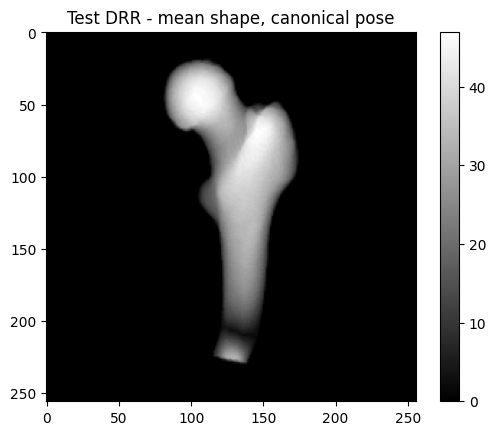

In [37]:
import numpy as np

drr = cone_beam_project_torch(
    volume=filled_matrix,
    voxel_pitch=1.0,
    sdd=1000.0,
    sod=800.0,
    pixel_spacing=1.1481,
    output_size=(256, 256),
    ap_axis=1,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(drr.min(), drr.max(), drr.shape)
plt.imshow(drr, cmap='gray')
plt.title('Test DRR - mean shape, canonical pose')
plt.colorbar()
plt.savefig('meanshape_drr.png')

**Eigen vectors from ssm**

In [9]:
import numpy as np

location1 =r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\ssm_basis\eigenvectors.npy'
data = np.load(location1)
eigenvectors = data[:5]

# Print the array contents
print(eigenvectors)


[[-0.00042662 -0.00240114 -0.00681031 ... -0.00042873  0.0022811
   0.01085113]
 [ 0.00333708 -0.00832499 -0.00391668 ... -0.0033604  -0.00070032
   0.00105163]
 [ 0.00725902  0.00401192 -0.00456556 ... -0.00179843 -0.01220611
  -0.00104283]
 [ 0.01019132 -0.00064115 -0.00095295 ...  0.0095454   0.01370144
   0.0043609 ]
 [ 0.0041367   0.00354933  0.00665366 ... -0.00879889 -0.00927068
  -0.0027694 ]]


**Sigma from ssm**

In [10]:
import numpy as np

location2 =r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\ssm_basis\sigma.npy'
data = np.load(location2)
sigma = data[:5]

# Print the array contents
print(sigma)


[1853.54425145  405.83531725  307.3041873   247.18201026  177.58565124]


**Loading mean shape**

In [11]:
mesh_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Visualization_of_p_values\mean_shape.stl"

In [12]:
template_mesh = trimesh.load(mesh_folder)

template_vertices = template_mesh.vertices

template_faces = template_mesh.faces

print(template_vertices.shape)
print(template_faces.shape)

(24431, 3)
(48718, 3)


**Generating Synthetic DRRs from .csv files** 

In [ ]:
import os
import pandas as pd
import trimesh

# ==========================================================
# GPU (CuPy) if available
# ==========================================================

try:
    import cupy as cp
    xp = cp
    GPU = True
    print("Using GPU (CuPy)")
except ImportError:
    import numpy as np
    xp = np
    GPU = False
    print("CuPy not found. Using CPU.")

# ==========================================================
# INPUTS (already available in your workspace)
#
# mean_shape      -> (73293,)
# sigma           -> (5,)
# eigenvectors    -> (5,73293)
# template_mesh   -> trimesh mesh
# ==========================================================

# Move arrays to GPU if available
mean_gpu = xp.asarray(mean_shape)
sigma_gpu = xp.asarray(sigma)
eigen_gpu = xp.asarray(eigenvectors)

# ==========================================================
# CSV PATH
# ==========================================================

csv_path = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\1436_pvectors.csv"

df = pd.read_csv(csv_path)

p_vectors = df[["p1", "p2", "p3", "p4", "p5"]].values

# ==========================================================
# OUTPUT FOLDER
# ==========================================================

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# GENERATE ALL SYNTHETIC FEMURS
# ==========================================================

for idx, p in enumerate(p_vectors, start=1):

    p_gpu = xp.asarray(p)

    # ---------------------------------------
    # PCA reconstruction
    # ---------------------------------------

    reconstructed = mean_gpu + xp.sum(
        p_gpu[:, None] *
        sigma_gpu[:, None] *
        eigen_gpu,
        axis=0
    )

    # ---------------------------------------
    # Move back to CPU
    # ---------------------------------------

    if GPU:
        reconstructed = cp.asnumpy(reconstructed)

    vertices = reconstructed.reshape(-1, 3)

    # ---------------------------------------
    # Create mesh
    # ---------------------------------------

    mesh = trimesh.Trimesh(
        vertices=vertices,
        faces=template_mesh.faces,
        process=False
    )

    # ---------------------------------------
    # Export
    # ---------------------------------------

    out_path = os.path.join(
        output_folder,
        f"synthetic_femur_{idx}.stl"
    )

    mesh.export(out_path)

    if idx % 50 == 0 or idx == len(p_vectors):
        print(f"{idx}/{len(p_vectors)} completed")

print("\nFinished generating all synthetic femurs.")

**Making files water tight**

In [ ]:
import os
import trimesh
import numpy as np

# ==========================================================
# INPUT / OUTPUT FOLDERS
# ==========================================================

input_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs"

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# GET ALL STL FILES
# ==========================================================

stl_files = sorted(
    [
        f for f in os.listdir(input_folder)
        if f.lower().endswith(".stl")
    ],
    key=lambda x: int(x.split("_")[-1].split(".")[0])
)

print(f"Found {len(stl_files)} STL files.\n")

# ==========================================================
# PROCESS EACH MESH
# ==========================================================

for idx, filename in enumerate(stl_files, start=1):

    print("=" * 60)
    print(f"Processing {filename}")

    mesh_path = os.path.join(input_folder, filename)

    mesh = trimesh.load(mesh_path)

    # ------------------------------------------------------
    # Find boundary loops
    # ------------------------------------------------------

    outline = mesh.outline()

    if len(outline.entities) == 0:
        print("No boundary found. Skipping.")
        continue

    loop_vertices_idx = outline.entities[0].points
    loop_pts = mesh.vertices[loop_vertices_idx]

    # ------------------------------------------------------
    # Create centroid
    # ------------------------------------------------------

    centroid = loop_pts.mean(axis=0)

    new_vertex_idx = len(mesh.vertices)

    # ------------------------------------------------------
    # Fan triangulation
    # ------------------------------------------------------

    new_faces = []
    skipped = 0

    for i in range(len(loop_vertices_idx)):

        a = loop_vertices_idx[i]
        b = loop_vertices_idx[(i + 1) % len(loop_vertices_idx)]

        pa = mesh.vertices[a]
        pb = mesh.vertices[b]

        area = 0.5 * np.linalg.norm(
            np.cross(pb - pa, centroid - pa)
        )

        if area < 1e-6:
            skipped += 1
            continue

        new_faces.append([a, b, new_vertex_idx])

    print(f"Skipped {skipped} degenerate fan triangles")

    # ------------------------------------------------------
    # Add centroid
    # ------------------------------------------------------

    new_vertices = np.vstack(
        [mesh.vertices, centroid]
    )

    new_faces_arr = np.vstack(
        [
            mesh.faces,
            np.array(new_faces, dtype=np.int64)
        ]
    )

    # ------------------------------------------------------
    # Create capped mesh
    # ------------------------------------------------------

    capped_mesh = trimesh.Trimesh(
        vertices=new_vertices,
        faces=new_faces_arr,
        process=True
    )

    # ------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------

    capped_mesh.update_faces(
        capped_mesh.unique_faces()
    )

    capped_mesh.update_faces(
        capped_mesh.nondegenerate_faces()
    )

    capped_mesh.remove_unreferenced_vertices()

    capped_mesh.fix_normals()

    # ------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------

    print("Watertight:", capped_mesh.is_watertight)
    print("Winding consistent:", capped_mesh.is_winding_consistent)
    print("Extents:", capped_mesh.extents)

    # ------------------------------------------------------
    # Save
    # ------------------------------------------------------

    output_path = os.path.join(
        output_folder,
        f"Synthetic_femur_capped_{idx}.stl"
    )

    capped_mesh.export(output_path)

    print("Saved:", output_path)

print("\nAll meshes processed successfully.")

**Creating .npy files for all the Synthetic capped femurs**

In [ ]:
import os
import numpy as np
import trimesh

# ==========================================================
# INPUT / OUTPUT FOLDERS
# ==========================================================

input_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped"

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped\Voxel_npy"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# VOXELIZATION SETTINGS
# ==========================================================

PITCH = 1.0  # mm

# ==========================================================
# GET STL FILES
# ==========================================================

stl_files = sorted(
    [
        f for f in os.listdir(input_folder)
        if f.lower().endswith(".stl")
    ],
    key=lambda x: int(x.split("_")[-1].split(".")[0])
)

print(f"Found {len(stl_files)} STL files.\n")

# ==========================================================
# PROCESS EACH SYNTHETIC FEMUR
# ==========================================================

for idx, filename in enumerate(stl_files, start=1):

    print("=" * 60)
    print(f"{idx}/{len(stl_files)} : {filename}")

    mesh_path = os.path.join(input_folder, filename)

    mesh = trimesh.load(mesh_path, process=False)

    # ------------------------------------------------------
    # Sanity check
    # ------------------------------------------------------

    if not mesh.is_watertight:
        print("WARNING: Mesh is not watertight!")

    # ------------------------------------------------------
    # Voxelize
    # ------------------------------------------------------

    voxel_grid = mesh.voxelized(pitch=PITCH)

    # Fill interior
    voxel_grid = voxel_grid.fill()

    voxel_matrix = voxel_grid.matrix.astype(bool)

    # ------------------------------------------------------
    # Save voxel matrix
    # ------------------------------------------------------

    save_path = os.path.join(
        output_folder,
        f"synthetic_femur_{idx}.npy"
    )

    np.save(save_path, voxel_matrix)

    # ------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------

    occupied = voxel_matrix.sum()
    total = voxel_matrix.size

    print(f"Shape       : {voxel_matrix.shape}")
    print(f"Occupied    : {occupied}")
    print(f"Occupancy   : {occupied/total:.4f}")

print("\n========================================")
print("Finished voxelizing all synthetic femurs.")
print("========================================")

Found 1436 STL files.

1/1436 : Synthetic_femur_capped_1.stl
Shape       : (84, 87, 179)
Occupied    : 163168
Occupancy   : 0.1247
2/1436 : Synthetic_femur_capped_2.stl
Shape       : (85, 78, 162)
Occupied    : 151235
Occupancy   : 0.1408
3/1436 : Synthetic_femur_capped_3.stl
Shape       : (86, 73, 143)
Occupied    : 139503
Occupancy   : 0.1554
4/1436 : Synthetic_femur_capped_4.stl
Shape       : (88, 71, 126)
Occupied    : 128125
Occupancy   : 0.1628
5/1436 : Synthetic_femur_capped_5.stl
Shape       : (84, 87, 178)
Occupied    : 160782
Occupancy   : 0.1236
6/1436 : Synthetic_femur_capped_6.stl
Shape       : (84, 80, 161)
Occupied    : 145940
Occupancy   : 0.1349
7/1436 : Synthetic_femur_capped_7.stl
Shape       : (84, 73, 143)
Occupied    : 131567
Occupancy   : 0.1500
8/1436 : Synthetic_femur_capped_8.stl
Shape       : (85, 67, 125)
Occupied    : 117613
Occupancy   : 0.1652
9/1436 : Synthetic_femur_capped_9.stl
Shape       : (82, 89, 179)
Occupied    : 158315
Occupancy   : 0.1212
10/14

**Testing**

In [2]:
z=r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped\Synthetic_femur_capped_1.stl'

In [3]:
import trimesh

# Load the STL file
# Use process=False if you want to keep the raw data intact
mesh = trimesh.load(z)

# Check if the mesh is watertight
is_watertight = mesh.is_watertight

if is_watertight:
    print("The STL file is watertight!")
else:
    print("The STL file is NOT watertight. It may have holes or non-manifold edges.")

# Additional useful checks:
print(f"Number of disconnected parts (shells): {len(mesh.split())}")
print(f"Number of Euler edges: {mesh.euler_number}")


The STL file is watertight!
Number of disconnected parts (shells): 1
Number of Euler edges: 2


**Visualizing voxel working**

Shape: (74, 69, 144)
Occupied voxels: 132321


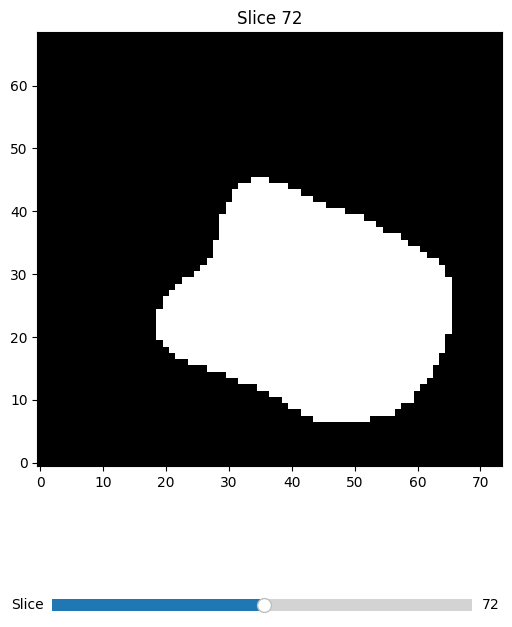

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ======================================================
# Load voxel matrix
# ======================================================

voxel_path = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped\Voxel_npy\synthetic_femur_67.npy"

voxel_matrix = np.load(voxel_path)

print("Shape:", voxel_matrix.shape)
print("Occupied voxels:", voxel_matrix.sum())

# ======================================================
# Initial slice
# ======================================================

initial_slice = voxel_matrix.shape[2] // 2

fig, ax = plt.subplots(figsize=(6, 8))
plt.subplots_adjust(bottom=0.20)

img = ax.imshow(
    voxel_matrix[:, :, initial_slice].T,
    cmap="gray",
    origin="lower"
)

ax.set_title(f"Slice {initial_slice}")

# ======================================================
# Slider
# ======================================================

slider_ax = plt.axes([0.15, 0.08, 0.70, 0.03])

slider = Slider(
    ax=slider_ax,
    label="Slice",
    valmin=0,
    valmax=voxel_matrix.shape[2]-1,
    valinit=initial_slice,
    valstep=1
)

# ======================================================
# Update function
# ======================================================

def update(val):

    s = int(slider.val)

    img.set_data(
        voxel_matrix[:, :, s].T
    )

    ax.set_title(f"Slice {s}")

    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()

**Generating Synthetic DATA using .npy files**

In [4]:
import os
import numpy as np
import torch
import imageio.v2 as imageio
from tqdm import tqdm

# ==========================================================
# INPUT / OUTPUT
# ==========================================================

input_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\capped\Voxel_npy"

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\DRRs"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# GEOMETRY (LOCKED PARAMETERS)
# ==========================================================

VOXEL_PITCH = 1.0      # mm
SDD = 1000.0           # Source-to-detector distance (mm)
SOD = 800.0            # Source-to-object distance (mm)
PIXEL_SPACING = 1.1481 # mm
OUTPUT_SIZE = (256,256)
AP_AXIS = 1            # Y-axis

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================================
# CONE BEAM PROJECTOR
# ==========================================================

def cone_beam_project_torch(volume,
                            voxel_pitch,
                            sdd,
                            sod,
                            pixel_spacing,
                            output_size=(256,256),
                            ap_axis=1,
                            device='cuda'):

    with torch.no_grad():

        vol = torch.as_tensor(
            volume,
            dtype=torch.float32,
            device=device
        )

        vol_shape = torch.tensor(
            vol.shape,
            dtype=torch.float32,
            device=device
        )

        vol_center = vol_shape / 2.0

        H, W = output_size

        other_axes = [i for i in range(3) if i != ap_axis]

        # --------------------------------------------------
        # Source
        # --------------------------------------------------

        source = torch.zeros(3, device=device)

        source[ap_axis] = -sod / voxel_pitch

        # --------------------------------------------------
        # Detector
        # --------------------------------------------------

        rows = torch.arange(
            H,
            device=device,
            dtype=torch.float32
        )

        cols = torch.arange(
            W,
            device=device,
            dtype=torch.float32
        )

        det_v = (
            (rows - H/2 + 0.5)
            * pixel_spacing
            / voxel_pitch
        )

        det_u = (
            (cols - W/2 + 0.5)
            * pixel_spacing
            / voxel_pitch
        )

        det_pos = torch.zeros(
            H,
            W,
            3,
            device=device
        )

        det_pos[:,:,ap_axis] = (
            (sdd-sod)
            / voxel_pitch
        )

        det_pos[:,:,other_axes[0]] = det_u.view(1,W)

        det_pos[:,:,other_axes[1]] = det_v.view(H,1)

        # --------------------------------------------------
        # Rays
        # --------------------------------------------------

        ray_vec = det_pos-source.view(1,1,3)

        ray_length = torch.norm(
            ray_vec,
            dim=-1,
            keepdim=True
        )

        ray_dir = ray_vec/ray_length

        max_length = ray_length.max().item()

        num_samples = int(max_length*1.2)

        t_vals = torch.linspace(
            0,
            max_length,
            num_samples,
            device=device
        )

        positions = (
            source.view(1,1,1,3)
            + t_vals.view(1,1,-1,1)
            * ray_dir.unsqueeze(2)
            + vol_center.view(1,1,1,3)
        )

        norm_pos = torch.empty_like(positions)

        norm_pos[...,0] = (
            positions[...,2]
            /(vol.shape[2]-1)
            *2
            -1
        )

        norm_pos[...,1] = (
            positions[...,1]
            /(vol.shape[1]-1)
            *2
            -1
        )

        norm_pos[...,2] = (
            positions[...,0]
            /(vol.shape[0]-1)
            *2
            -1
        )

        grid = norm_pos.view(
            1,
            H,
            W*num_samples,
            1,
            3
        )

        vol5d = vol.view(
            1,
            1,
            vol.shape[0],
            vol.shape[1],
            vol.shape[2]
        )

        sampled = torch.nn.functional.grid_sample(
            vol5d,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        )

        sampled = sampled.view(
            H,
            W,
            num_samples
        )

        drr = sampled.sum(dim=-1)

        return drr.cpu().numpy()

# ==========================================================
# PROCESS ALL VOXELS
# ==========================================================

files = sorted(
    [
        f for f in os.listdir(input_folder)
        if f.endswith(".npy")
    ],
    key=lambda x:int(
        x.split("_")[-1].split(".")[0]
    )
)

print("Number of volumes:",len(files))

for idx,file in enumerate(tqdm(files),start=1):

    volume = np.load(
        os.path.join(input_folder,file)
    )

    drr = cone_beam_project_torch(
        volume,
        voxel_pitch=VOXEL_PITCH,
        sdd=SDD,
        sod=SOD,
        pixel_spacing=PIXEL_SPACING,
        output_size=OUTPUT_SIZE,
        ap_axis=AP_AXIS,
        device=DEVICE
    )

    # ------------------------------------------
    # Normalize to 0-255
    # ------------------------------------------

    drr -= drr.min()

    drr /= (
        drr.max()+1e-8
    )

    drr = (
        drr*255
    ).astype(np.uint8)

    imageio.imwrite(
        os.path.join(
            output_folder,
            f"synthetic_femur_{idx}.png"
        ),
        drr
    )

print("\nFinished generating all DRRs.")

Using device: cuda
Number of volumes: 1436


100%|██████████| 1436/1436 [04:21<00:00,  5.49it/s]


Finished generating all DRRs.


**Split into train test and validation**

In [3]:
import shutil
import random
from pathlib import Path

# ---- CONFIG ----
SOURCE_DIR = Path(r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\DRRs")
OUTPUT_DIR = Path(r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split")
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42
EXT = "*.png"  # change if your DRRs are .tif/.jpg/etc

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Ratios must sum to 1"

random.seed(SEED)

# ---- COLLECT FILES ----
image_paths = sorted(SOURCE_DIR.glob(EXT))
n_total = len(image_paths)
print(f"Found {n_total} images")

if n_total != 1436:
    print(f"WARNING: expected 1436, found {n_total}. Check EXT or SOURCE_DIR before proceeding.")

# ---- SHUFFLE AND SPLIT ----
random.shuffle(image_paths)

n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)
n_test = n_total - n_train - n_val  # remainder goes to test, avoids rounding loss

train_files = image_paths[:n_train]
val_files = image_paths[n_train:n_train + n_val]
test_files = image_paths[n_train + n_val:]

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

# ---- COPY (not move — keep your original DRRs untouched) ----
for split_name, files in [("train", train_files), ("val", val_files), ("test", test_files)]:
    split_dir = OUTPUT_DIR / split_name
    split_dir.mkdir(parents=True, exist_ok=True)
    for f in files:
        shutil.copy2(f, split_dir / f.name)

print("Done. Verify counts:")
for split_name in ["train", "val", "test"]:
    split_dir = OUTPUT_DIR / split_name
    count = len(list(split_dir.glob(EXT)))
    print(f"  {split_name}: {count}")

Found 1436 images
Train: 1005, Val: 215, Test: 216
Done. Verify counts:
  train: 1005
  val: 215
  test: 216


**Augmented 15 variations per femur**

In [4]:
import albumentations as A
import cv2
from pathlib import Path

# ==========================================================
# PATHS
# ==========================================================

BASE_DIR = Path(r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Synthetic femurs\Split")

SPLITS = ["train", "val", "test"]

N_AUGMENTS = 14

# ==========================================================
# AUGMENTATION PIPELINE
# ==========================================================

transform = A.Compose([
    A.Affine(
        translate_percent={"x": (-0.1, 0.1),
                           "y": (-0.1, 0.1)},
        rotate=(-10, 10),
        scale=(0.85, 1.15),
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        p=1.0,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0,
        contrast_limit=0.15,
        p=1.0,
    ),
])

# ==========================================================
# AUGMENT ONE SPLIT
# ==========================================================

def augment_split(split_name):

    folder = BASE_DIR / split_name

    image_paths = sorted(folder.glob("*.png"))

    # Ignore previously augmented images
    image_paths = [
        p for p in image_paths
        if "_aug" not in p.stem and "_orig" not in p.stem
    ]

    print(f"\n[{split_name}] Found {len(image_paths)} original images")

    for img_path in image_paths:

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Could not load {img_path}")
            continue

        stem = img_path.stem

        # Create 14 augmented versions
        for i in range(N_AUGMENTS):

            aug = transform(image=img)["image"]

            save_path = folder / f"{stem}_aug{i:02d}.png"

            cv2.imwrite(str(save_path), aug)

    total = len(list(folder.glob("*.png")))

    expected = len(image_paths) * (N_AUGMENTS + 1)

    print(f"[{split_name}]")
    print(f"Original images : {len(image_paths)}")
    print(f"Expected total  : {expected}")
    print(f"Actual total    : {total}")

    assert total == expected, "Image count mismatch!"

# ==========================================================
# RUN
# ==========================================================

for split in SPLITS:
    augment_split(split)

print("\nAll augmentations completed successfully.")


[train] Found 1005 original images
[train]
Original images : 1005
Expected total  : 15075
Actual total    : 15075

[val] Found 215 original images
[val]
Original images : 215
Expected total  : 3225
Actual total    : 3225

[test] Found 216 original images
[test]
Original images : 216
Expected total  : 3240
Actual total    : 3240

All augmentations completed successfully.
